<a href="https://colab.research.google.com/github/asheta66/Data-Mining/blob/main/GA/Metaheuristic_Feature_Selection_SVM_Enhanced.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Metaheuristic Feature Selection with SVM on Three Medical Datasets

This notebook compares four binary wrapper-based feature-selection algorithms on three datasets:

1. **Chronic Kidney Disease**
2. **Heart Disease Collections**
3. **Breast Cancer Wisconsin**

The optimizers are **Genetic Algorithm (GA)**, **Particle Swarm Optimization (PSO)**, **Salp Swarm Algorithm (SSA)**, and **Crow Search Algorithm (CSA)**. All selected subsets and the all-features baseline are classified using a **class-weighted RBF Support Vector Machine (SVM)**.

All four methods optimize the same objective:

\[
\text{Fitness} = \alpha\,(\text{CV F1}) + (1-\alpha)\left(1-\frac{k}{d}\right)
\]

where \(k\) is the number of selected features and \(d\) is the total number of features. Higher fitness is better. The test set is not used during feature selection.

In [1]:
import math
import time
import warnings
from dataclasses import dataclass, asdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.datasets import load_breast_cancer, make_classification
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 180)
RANDOM_STATE = 42

# Every figure generated by this notebook is saved here.
FIGURE_DIR = Path('saved_figures')
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DPI = 160

def safe_filename(text):
    return ''.join(ch.lower() if ch.isalnum() else '_' for ch in text).strip('_')

def save_and_show(fig, filename):
    path = FIGURE_DIR / filename
    fig.savefig(path, dpi=FIGURE_DPI, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    print(f'Saved: {path}')

## 1. Dataset access

The loader first checks the local `data/` folder. Set `USE_KAGGLE=True` after configuring Kaggle credentials to download the named datasets. When a CSV is unavailable, a deterministic offline fallback is used so the notebook remains executable.

In [2]:
USE_KAGGLE = False
DATA_DIR = Path('data')
DATA_DIR.mkdir(exist_ok=True)

KAGGLE_DATASETS = {
    'Chronic Kidney Disease': {
        'handle': 'colearninglounge/chronic-kidney-disease',
        'local_candidates': ['kidney_disease.csv', 'ckd.csv'],
        'target_candidates': ['classification', 'Class', 'Diagnosis', 'target']
    },
    'Heart Disease Collections': {
        'handle': 'johnsmith88/heart-disease-dataset',
        'local_candidates': ['heart.csv', 'heart_disease.csv'],
        'target_candidates': ['target', 'condition', 'HeartDisease', 'output']
    },
    'Breast Cancer Wisconsin': {
        'handle': 'uciml/breast-cancer-wisconsin-data',
        'local_candidates': ['data.csv', 'breast_cancer.csv'],
        'target_candidates': ['diagnosis', 'target', 'Class']
    },
}

def _find_csv(folder, candidates):
    folder = Path(folder)
    for name in candidates:
        p = folder / name
        if p.exists():
            return p
    csvs = list(folder.rglob('*.csv')) if folder.exists() else []
    return csvs[0] if csvs else None

def _encode_target(series):
    s = series.astype(str).str.strip().str.lower()
    mapping = {
        'ckd': 1, 'notckd': 0, 'not ckd': 0,
        'm': 1, 'b': 0, 'malignant': 1, 'benign': 0,
        'yes': 1, 'no': 0, 'positive': 1, 'negative': 0,
        'true': 1, 'false': 0
    }
    mapped = s.map(mapping)
    if mapped.notna().all():
        return mapped.astype(int)
    numeric = pd.to_numeric(series, errors='coerce')
    if numeric.notna().all():
        unique = sorted(numeric.unique())
        if len(unique) == 2:
            return numeric.map({unique[0]: 0, unique[1]: 1}).astype(int)
    encoded = LabelEncoder().fit_transform(s)
    if len(np.unique(encoded)) != 2:
        raise ValueError('The target must be binary for this notebook.')
    return pd.Series(encoded, index=series.index).astype(int)

def _prepare_dataframe(df, target_candidates):
    df = df.copy()
    df.columns = [str(c).strip() for c in df.columns]
    target = next((c for c in target_candidates if c in df.columns), None)
    if target is None:
        raise ValueError(f'Could not identify target column. Available columns: {list(df.columns)}')
    y = _encode_target(df.pop(target))
    drop_cols = [c for c in df.columns if c.lower().startswith('unnamed') or c.lower() in {'id','patientid','patient_id','name'}]
    X = df.drop(columns=drop_cols, errors='ignore')
    X = pd.get_dummies(X, drop_first=False)
    X = X.apply(pd.to_numeric, errors='coerce').replace([np.inf, -np.inf], np.nan)
    X = X.loc[:, X.notna().any(axis=0)]
    return X, y

def _simulate_medical_dataset(name):
    specs = {
        'Chronic Kidney Disease': (400, 24, 10, 4, 0.64),
        'Heart Disease Collections': (500, 13, 7, 3, 0.54),
    }
    n_samples, n_features, n_informative, n_redundant, positive_weight = specs[name]
    X, y = make_classification(
        n_samples=n_samples, n_features=n_features,
        n_informative=n_informative, n_redundant=n_redundant,
        n_classes=2, weights=[1-positive_weight, positive_weight],
        class_sep=1.15, flip_y=0.025,
        random_state=RANDOM_STATE + n_features
    )
    names = [f'{name.split()[0].lower()}_feature_{i+1}' for i in range(n_features)]
    return pd.DataFrame(X, columns=names), pd.Series(y, name='target')

def load_dataset(name):
    info = KAGGLE_DATASETS[name]
    csv_path = _find_csv(DATA_DIR, info['local_candidates'])
    source = None
    if csv_path is None and USE_KAGGLE:
        try:
            import kagglehub
            downloaded = Path(kagglehub.dataset_download(info['handle']))
            csv_path = _find_csv(downloaded, info['local_candidates'])
            source = f'Kaggle: {info["handle"]}'
        except Exception as exc:
            print(f'Kaggle download unavailable for {name}: {exc}')
    if csv_path is not None:
        X, y = _prepare_dataframe(pd.read_csv(csv_path), info['target_candidates'])
        source = source or f'Local CSV: {csv_path}'
    elif name == 'Breast Cancer Wisconsin':
        built_in = load_breast_cancer(as_frame=True)
        X, y = built_in.data.copy(), 1 - built_in.target.copy()  # positive = malignant
        source = 'scikit-learn offline copy of Breast Cancer Wisconsin'
    else:
        X, y = _simulate_medical_dataset(name)
        source = 'Deterministic simulated fallback; replace with Kaggle CSV for study results'
    return X.reset_index(drop=True), y.reset_index(drop=True), source

datasets = {}
summary = []
for dataset_name in KAGGLE_DATASETS:
    X, y, source = load_dataset(dataset_name)
    datasets[dataset_name] = (X, y)
    summary.append({
        'Dataset': dataset_name,
        'Rows': len(X),
        'Input features': X.shape[1],
        'Positive class %': round(100*y.mean(), 2),
        'Data source used': source,
        'Kaggle handle': KAGGLE_DATASETS[dataset_name]['handle']
    })
dataset_summary_df = pd.DataFrame(summary)
dataset_summary_df

,Dataset,Rows,Input features,Positive class %,Data source used,Kaggle handle
0,Chronic Kidney Disease,400,24,64.50,Deterministic simulated fallback; replace with...,colearninglounge/chronic-kidney-disease
1,Heart Disease Collections,500,13,53.40,Deterministic simulated fallback; replace with...,johnsmith88/heart-disease-dataset
2,Breast Cancer Wisconsin,569,30,37.26,scikit-learn offline copy of Breast Cancer Wis...,uciml/breast-cancer-wisconsin-data


## 2. Classification algorithm adopted

The same SVM pipeline is used for the all-features baseline and every selected-feature subset. Median imputation and standardization are fitted inside the pipeline, preventing preprocessing leakage.

In [3]:
def make_classifier():
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', SVC(
            kernel='rbf',
            C=1.0,
            gamma='scale',
            class_weight='balanced',
            random_state=RANDOM_STATE
        ))
    ])

CLASSIFIERS = {
    'Chronic Kidney Disease': make_classifier(),
    'Heart Disease Collections': make_classifier(),
    'Breast Cancer Wisconsin': make_classifier(),
}

classifier_df = pd.DataFrame([
    {
        'Dataset': name,
        'Classification algorithm': 'Support Vector Machine (RBF-SVM)',
        'SVM kernel': 'RBF',
        'C': 1.0,
        'Gamma': 'scale',
        'Preprocessing': 'Median imputation + standardization',
        'Class weighting': 'Balanced'
    }
    for name in CLASSIFIERS
])
classifier_df

,Dataset,Classification algorithm,SVM kernel,C,Gamma,Preprocessing,Class weighting
0,Chronic Kidney Disease,Support Vector Machine (RBF-SVM),RBF,1.0,scale,Median imputation + standardization,Balanced
1,Heart Disease Collections,Support Vector Machine (RBF-SVM),RBF,1.0,scale,Median imputation + standardization,Balanced
2,Breast Cancer Wisconsin,Support Vector Machine (RBF-SVM),RBF,1.0,scale,Median imputation + standardization,Balanced


## 3. Editable common search and fitness settings

The population and number of generations/iterations have been increased for more stable searches. These values apply equally to GA, PSO, SSA, and CSA to support a fair comparison.

In [4]:
@dataclass(frozen=True)
class CommonConfig:
    population_size: int = 30
    iterations: int = 25
    cv_folds: int = 3
    fitness_weight_f1: float = 0.90
    random_state: int = 42

COMMON_CONFIG = CommonConfig()
pd.DataFrame([asdict(COMMON_CONFIG)])

,population_size,iterations,cv_folds,fitness_weight_f1,random_state
0,30,25,3,0.9,42


## 4. GA tuning parameters — editable cell

In [5]:
@dataclass(frozen=True)
class GAConfig:
    crossover_rate: float = 0.80
    mutation_rate: float = 0.05
    elite_size: int = 2
    tournament_size: int = 3

GA_CONFIG = GAConfig()
pd.DataFrame([asdict(GA_CONFIG)])

,crossover_rate,mutation_rate,elite_size,tournament_size
0,0.8,0.05,2,3


## 5. PSO tuning parameters — editable cell

In [6]:
@dataclass(frozen=True)
class PSOConfig:
    inertia: float = 0.72
    cognitive: float = 1.49
    social: float = 1.49

PSO_CONFIG = PSOConfig()
pd.DataFrame([asdict(PSO_CONFIG)])

,inertia,cognitive,social
0,0.72,1.49,1.49


## 6. SSA tuning parameters — editable cell

In [7]:
@dataclass(frozen=True)
class SSAConfig:
    binary_threshold: float = 0.50

SSA_CONFIG = SSAConfig()
pd.DataFrame([asdict(SSA_CONFIG)])

,binary_threshold
0,0.5


## 7. CSA tuning parameters — editable cell

In [8]:
@dataclass(frozen=True)
class CSAConfig:
    awareness_probability: float = 0.10
    flight_length: float = 2.0

CSA_CONFIG = CSAConfig()
pd.DataFrame([asdict(CSA_CONFIG)])

,awareness_probability,flight_length
0,0.1,2.0


## 8. Shared binary representation and fitness

Each candidate is a binary vector. A value of **1** selects a feature, and **0** excludes it. The convergence curves plot the best-so-far value of the same fitness used to guide every search.

In [9]:
def ensure_nonempty(mask, rng):
    mask = np.asarray(mask, dtype=int).copy()
    if mask.sum() == 0:
        mask[rng.integers(0, len(mask))] = 1
    return mask

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -20, 20)))

def make_fitness(X, y, classifier, config):
    cv = StratifiedKFold(n_splits=config.cv_folds, shuffle=True, random_state=config.random_state)
    cache = {}
    def fitness(mask):
        mask = ensure_nonempty(mask, np.random.default_rng(config.random_state))
        key = tuple(mask.tolist())
        if key in cache:
            return cache[key]
        selected_ratio = mask.sum() / len(mask)
        cv_f1 = cross_val_score(
            clone(classifier), X.iloc[:, mask == 1], y,
            cv=cv, scoring='f1', n_jobs=1
        ).mean()
        reduction = 1.0 - selected_ratio
        value = config.fitness_weight_f1 * cv_f1 + (1-config.fitness_weight_f1) * reduction
        cache[key] = float(value)
        return float(value)
    return fitness

def evaluate_population(population, fitness_fn):
    return np.array([fitness_fn(ind) for ind in population], dtype=float)

## 9. Binary optimization algorithms

In [10]:
def run_ga(X, y, classifier, common, specific):
    rng = np.random.default_rng(common.random_state)
    n_features = X.shape[1]
    fitness_fn = make_fitness(X, y, classifier, common)
    pop = rng.integers(0, 2, size=(common.population_size, n_features))
    pop = np.array([ensure_nonempty(ind, rng) for ind in pop])
    best_mask, best_score, history = None, -np.inf, []

    def tournament(scores):
        idx = rng.choice(len(pop), size=min(specific.tournament_size, len(pop)), replace=False)
        return pop[idx[np.argmax(scores[idx])]].copy()

    for _ in range(common.iterations):
        scores = evaluate_population(pop, fitness_fn)
        order = np.argsort(scores)[::-1]
        if scores[order[0]] > best_score:
            best_score, best_mask = scores[order[0]], pop[order[0]].copy()
        history.append(best_score)
        new_pop = [pop[i].copy() for i in order[:specific.elite_size]]
        while len(new_pop) < common.population_size:
            p1, p2 = tournament(scores), tournament(scores)
            if rng.random() < specific.crossover_rate and n_features > 1:
                point = rng.integers(1, n_features)
                children = [np.r_[p1[:point], p2[point:]], np.r_[p2[:point], p1[point:]]]
            else:
                children = [p1.copy(), p2.copy()]
            for child in children:
                flips = rng.random(n_features) < specific.mutation_rate
                child[flips] = 1-child[flips]
                new_pop.append(ensure_nonempty(child, rng))
                if len(new_pop) >= common.population_size:
                    break
        pop = np.array(new_pop[:common.population_size])
    return best_mask, best_score, history

def run_pso(X, y, classifier, common, specific):
    rng = np.random.default_rng(common.random_state + 101)
    n, d = common.population_size, X.shape[1]
    fitness_fn = make_fitness(X, y, classifier, common)
    positions = np.array([ensure_nonempty(x, rng) for x in rng.integers(0,2,size=(n,d))])
    velocities = rng.uniform(-1,1,size=(n,d))
    scores = evaluate_population(positions, fitness_fn)
    pbest, pbest_scores = positions.copy(), scores.copy()
    idx = np.argmax(scores)
    gbest, gbest_score, history = positions[idx].copy(), scores[idx], []
    for _ in range(common.iterations):
        r1, r2 = rng.random((n,d)), rng.random((n,d))
        velocities = specific.inertia*velocities + specific.cognitive*r1*(pbest-positions) + specific.social*r2*(gbest-positions)
        positions = (rng.random((n,d)) < sigmoid(velocities)).astype(int)
        positions = np.array([ensure_nonempty(x,rng) for x in positions])
        scores = evaluate_population(positions, fitness_fn)
        improved = scores > pbest_scores
        pbest[improved], pbest_scores[improved] = positions[improved], scores[improved]
        idx = np.argmax(pbest_scores)
        if pbest_scores[idx] > gbest_score:
            gbest, gbest_score = pbest[idx].copy(), pbest_scores[idx]
        history.append(gbest_score)
    return gbest, gbest_score, history

def run_ssa(X, y, classifier, common, specific):
    rng = np.random.default_rng(common.random_state + 202)
    n, d = common.population_size, X.shape[1]
    fitness_fn = make_fitness(X, y, classifier, common)
    continuous = rng.random((n,d))
    binary = np.array([ensure_nonempty(x,rng) for x in (continuous >= specific.binary_threshold).astype(int)])
    scores = evaluate_population(binary, fitness_fn)
    idx = np.argmax(scores)
    food, food_score, best_mask, history = continuous[idx].copy(), scores[idx], binary[idx].copy(), []
    for t in range(common.iterations):
        c1 = 2*math.exp(-((4*(t+1)/common.iterations)**2))
        new_cont = continuous.copy()
        for i in range(n):
            if i == 0:
                c2, c3 = rng.random(d), rng.random(d)
                step = c1*c2
                new_cont[i] = np.where(c3 < 0.5, food+step, food-step)
            else:
                new_cont[i] = 0.5*(new_cont[i-1]+continuous[i])
        continuous = np.clip(new_cont,0,1)
        binary = (rng.random((n,d)) < sigmoid(10*(continuous-0.5))).astype(int)
        binary = np.array([ensure_nonempty(x,rng) for x in binary])
        scores = evaluate_population(binary, fitness_fn)
        idx = np.argmax(scores)
        if scores[idx] > food_score:
            food, food_score, best_mask = continuous[idx].copy(), scores[idx], binary[idx].copy()
        history.append(food_score)
    return best_mask, food_score, history

def run_csa(X, y, classifier, common, specific):
    rng = np.random.default_rng(common.random_state + 303)
    n, d = common.population_size, X.shape[1]
    fitness_fn = make_fitness(X, y, classifier, common)
    positions = rng.random((n,d))
    binary = np.array([ensure_nonempty(x,rng) for x in (positions >= 0.5).astype(int)])
    scores = evaluate_population(binary, fitness_fn)
    memories, memory_masks, memory_scores = positions.copy(), binary.copy(), scores.copy()
    idx = np.argmax(scores)
    best_mask, best_score, history = binary[idx].copy(), scores[idx], []
    for _ in range(common.iterations):
        new_positions = positions.copy()
        for i in range(n):
            j = rng.integers(0,n-1)
            if j >= i: j += 1
            if rng.random() >= specific.awareness_probability:
                new_positions[i] = positions[i] + specific.flight_length*rng.random(d)*(memories[j]-positions[i])
            else:
                new_positions[i] = rng.random(d)
        positions = np.clip(new_positions,0,1)
        binary = (rng.random((n,d)) < sigmoid(10*(positions-0.5))).astype(int)
        binary = np.array([ensure_nonempty(x,rng) for x in binary])
        scores = evaluate_population(binary, fitness_fn)
        improved = scores > memory_scores
        memories[improved], memory_masks[improved], memory_scores[improved] = positions[improved], binary[improved], scores[improved]
        idx = np.argmax(memory_scores)
        if memory_scores[idx] > best_score:
            best_mask, best_score = memory_masks[idx].copy(), memory_scores[idx]
        history.append(best_score)
    return best_mask, best_score, history

ALGORITHMS = {
    'GA': (run_ga, GA_CONFIG),
    'PSO': (run_pso, PSO_CONFIG),
    'SSA': (run_ssa, SSA_CONFIG),
    'CSA': (run_csa, CSA_CONFIG),
}

## 10. Run all-features baselines and feature-selection experiments

Each dataset uses the same stratified train/test split for all methods. The all-features baseline uses the same SVM classifier without feature selection. Models, predictions, and selected masks are retained for the best-result confusion matrices and heatmaps.

In [11]:
def calculate_metrics(y_true, y_pred):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1': f1_score(y_true, y_pred, zero_division=0),
    }

results = []
selected_feature_rows = []
convergence = {}
runtimes = {}
experiment_artifacts = {}
dataset_splits = {}

for dataset_name, (X, y) in datasets.items():
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
    )
    dataset_splits[dataset_name] = (X_train, X_test, y_train, y_test)
    classifier = CLASSIFIERS[dataset_name]

    # All-features baseline
    baseline_cols = X.columns.tolist()
    baseline = clone(classifier).fit(X_train, y_train)
    baseline_train_pred = baseline.predict(X_train)
    baseline_test_pred = baseline.predict(X_test)
    train_m = calculate_metrics(y_train, baseline_train_pred)
    test_m = calculate_metrics(y_test, baseline_test_pred)
    results.append({
        'Dataset': dataset_name, 'Method': 'All Features',
        'Classification algorithm': 'Support Vector Machine (RBF-SVM)',
        **{f'Train {k}': v for k, v in train_m.items()},
        **{f'Test {k}': v for k, v in test_m.items()},
        'Selected features': X.shape[1], 'Total features': X.shape[1],
        'Best fitness': np.nan
    })
    selected_feature_rows.append({
        'Dataset': dataset_name, 'Method': 'All Features',
        'Selected feature count': X.shape[1],
        'Selected feature names': ', '.join(baseline_cols)
    })
    experiment_artifacts[(dataset_name, 'All Features')] = {
        'model': baseline, 'columns': baseline_cols,
        'train_pred': baseline_train_pred, 'test_pred': baseline_test_pred
    }

    for name, (fn, specific) in ALGORITHMS.items():
        started = time.perf_counter()
        mask, best_fitness, history = fn(X_train, y_train, classifier, COMMON_CONFIG, specific)
        runtimes[(dataset_name, name)] = time.perf_counter() - started
        cols = X.columns[np.asarray(mask, dtype=bool)].tolist()
        model = clone(classifier).fit(X_train[cols], y_train)
        train_pred = model.predict(X_train[cols])
        test_pred = model.predict(X_test[cols])
        train_m = calculate_metrics(y_train, train_pred)
        test_m = calculate_metrics(y_test, test_pred)
        results.append({
            'Dataset': dataset_name, 'Method': name,
            'Classification algorithm': 'Support Vector Machine (RBF-SVM)',
            **{f'Train {k}': v for k, v in train_m.items()},
            **{f'Test {k}': v for k, v in test_m.items()},
            'Selected features': len(cols), 'Total features': X.shape[1],
            'Best fitness': best_fitness
        })
        selected_feature_rows.append({
            'Dataset': dataset_name, 'Method': name,
            'Selected feature count': len(cols),
            'Selected feature names': ', '.join(cols)
        })
        convergence[(dataset_name, name)] = history
        experiment_artifacts[(dataset_name, name)] = {
            'model': model, 'columns': cols,
            'train_pred': train_pred, 'test_pred': test_pred,
            'mask': np.asarray(mask, dtype=int)
        }
        print(f'{dataset_name} - {name}: {len(cols)}/{X.shape[1]} features, test F1={test_m["F1"]:.3f}')

results_df = pd.DataFrame(results)
selected_features_df = pd.DataFrame(selected_feature_rows)
print('All experiments completed.')

Chronic Kidney Disease - GA: 9/24 features, test F1=0.924
Chronic Kidney Disease - PSO: 10/24 features, test F1=0.911
Chronic Kidney Disease - SSA: 9/24 features, test F1=0.904
Chronic Kidney Disease - CSA: 9/24 features, test F1=0.949
Heart Disease Collections - GA: 6/13 features, test F1=0.924
Heart Disease Collections - PSO: 7/13 features, test F1=0.938
Heart Disease Collections - SSA: 6/13 features, test F1=0.932
Heart Disease Collections - CSA: 6/13 features, test F1=0.924
Breast Cancer Wisconsin - GA: 6/30 features, test F1=0.984
Breast Cancer Wisconsin - PSO: 7/30 features, test F1=0.952
Breast Cancer Wisconsin - SSA: 10/30 features, test F1=0.935
Breast Cancer Wisconsin - CSA: 8/30 features, test F1=0.976
All experiments completed.


## 11. Final result tables — one table per dataset

Each table contains the all-features baseline and the four feature-selection algorithms. Runtime is intentionally excluded.

In [12]:
DISPLAY_COLUMNS = [
    'Method','Classification algorithm',
    'Train Accuracy','Train Precision','Train Recall','Train F1',
    'Test Accuracy','Test Precision','Test Recall','Test F1',
    'Selected features','Total features','Best fitness'
]

dataset_result_tables = {}
for dataset_name in datasets:
    table = results_df.loc[results_df['Dataset'].eq(dataset_name), DISPLAY_COLUMNS].copy()
    numeric_cols = [c for c in table.columns if c not in ['Method','Classification algorithm','Selected features','Total features']]
    table[numeric_cols] = table[numeric_cols].round(4)
    dataset_result_tables[dataset_name] = table.reset_index(drop=True)
    print('\n' + dataset_name)
    display(dataset_result_tables[dataset_name])



Chronic Kidney Disease


,Method,Classification algorithm,Train Accuracy,Train Precision,Train Recall,Train F1,Test Accuracy,Test Precision,Test Recall,Test F1,Selected features,Total features,Best fitness
0,All Features,Support Vector Machine (RBF-SVM),0.9607,0.9830,0.9558,0.9692,0.8583,0.8846,0.8961,0.8903,24,24,NaN
1,GA,Support Vector Machine (RBF-SVM),0.9321,0.9551,0.9392,0.9471,0.9000,0.9012,0.9481,0.9241,9,24,0.8986
2,PSO,Support Vector Machine (RBF-SVM),0.9393,0.9556,0.9503,0.9529,0.8833,0.8889,0.9351,0.9114,10,24,0.8913
3,SSA,Support Vector Machine (RBF-SVM),0.9393,0.9505,0.9558,0.9532,0.8667,0.8427,0.9740,0.9036,9,24,0.8745
4,CSA,Support Vector Machine (RBF-SVM),0.9429,0.9558,0.9558,0.9558,0.9333,0.9367,0.9610,0.9487,9,24,0.8856



Heart Disease Collections


,Method,Classification algorithm,Train Accuracy,Train Precision,Train Recall,Train F1,Test Accuracy,Test Precision,Test Recall,Test F1,Selected features,Total features,Best fitness
0,All Features,Support Vector Machine (RBF-SVM),0.9314,0.9223,0.9519,0.9368,0.9067,0.9231,0.9000,0.9114,13,13,NaN
1,GA,Support Vector Machine (RBF-SVM),0.9200,0.9251,0.9251,0.9251,0.9200,0.9359,0.9125,0.9241,6,13,0.8718
2,PSO,Support Vector Machine (RBF-SVM),0.9286,0.9309,0.9358,0.9333,0.9333,0.9375,0.9375,0.9375,7,13,0.8645
3,SSA,Support Vector Machine (RBF-SVM),0.9171,0.9072,0.9412,0.9239,0.9267,0.9259,0.9375,0.9317,6,13,0.8579
4,CSA,Support Vector Machine (RBF-SVM),0.9200,0.9251,0.9251,0.9251,0.9200,0.9359,0.9125,0.9241,6,13,0.8718



Breast Cancer Wisconsin


,Method,Classification algorithm,Train Accuracy,Train Precision,Train Recall,Train F1,Test Accuracy,Test Precision,Test Recall,Test F1,Selected features,Total features,Best fitness
0,All Features,Support Vector Machine (RBF-SVM),0.9874,1.0000,0.9662,0.9828,0.9825,0.9841,0.9688,0.9764,30,30,NaN
1,GA,Support Vector Machine (RBF-SVM),0.9749,0.9792,0.9527,0.9658,0.9883,1.0000,0.9688,0.9841,6,30,0.9525
2,PSO,Support Vector Machine (RBF-SVM),0.9774,0.9728,0.9662,0.9695,0.9649,0.9677,0.9375,0.9524,7,30,0.9435
3,SSA,Support Vector Machine (RBF-SVM),0.9824,0.9862,0.9662,0.9761,0.9532,0.9667,0.9062,0.9355,10,30,0.9358
4,CSA,Support Vector Machine (RBF-SVM),0.9799,0.9795,0.9662,0.9728,0.9825,1.0000,0.9531,0.9760,8,30,0.9395


## 12. Selected feature names

In [13]:
selected_features_df

,Dataset,Method,Selected feature count,Selected feature names
0,Chronic Kidney Disease,All Features,24,"chronic_feature_1, chronic_feature_2, chronic_..."
1,Chronic Kidney Disease,GA,9,"chronic_feature_7, chronic_feature_9, chronic_..."
2,Chronic Kidney Disease,PSO,10,"chronic_feature_7, chronic_feature_8, chronic_..."
3,Chronic Kidney Disease,SSA,9,"chronic_feature_5, chronic_feature_7, chronic_..."
4,Chronic Kidney Disease,CSA,9,"chronic_feature_5, chronic_feature_7, chronic_..."
5,Heart Disease Collections,All Features,13,"heart_feature_1, heart_feature_2, heart_featur..."
6,Heart Disease Collections,GA,6,"heart_feature_1, heart_feature_2, heart_featur..."
7,Heart Disease Collections,PSO,7,"heart_feature_1, heart_feature_3, heart_featur..."
8,Heart Disease Collections,SSA,6,"heart_feature_1, heart_feature_2, heart_featur..."
9,Heart Disease Collections,CSA,6,"heart_feature_1, heart_feature_2, heart_featur..."


## 13. Best-so-far convergence curves

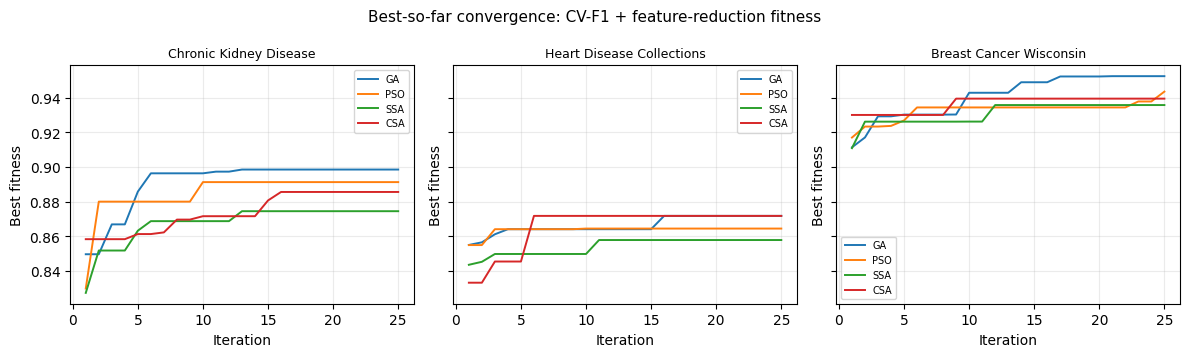

Saved: saved_figures/all_datasets_convergence.png


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), sharey=True)
for ax, dataset_name in zip(axes, datasets.keys()):
    for name in ALGORITHMS:
        hist = convergence[(dataset_name, name)]
        ax.plot(range(1, len(hist)+1), hist, linewidth=1.4, label=name)
    ax.set_title(dataset_name, fontsize=9)
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Best fitness')
    ax.grid(alpha=0.25)
    ax.legend(fontsize=7)
fig.suptitle('Best-so-far convergence: CV-F1 + feature-reduction fitness', fontsize=11)
fig.tight_layout()
save_and_show(fig, 'all_datasets_convergence.png')

## 14. Per-dataset result dashboards

Each dataset receives a 2×2 subplot showing convergence, testing metrics, training metrics, and selected-feature counts. The all-features baseline is included in the metric plots.

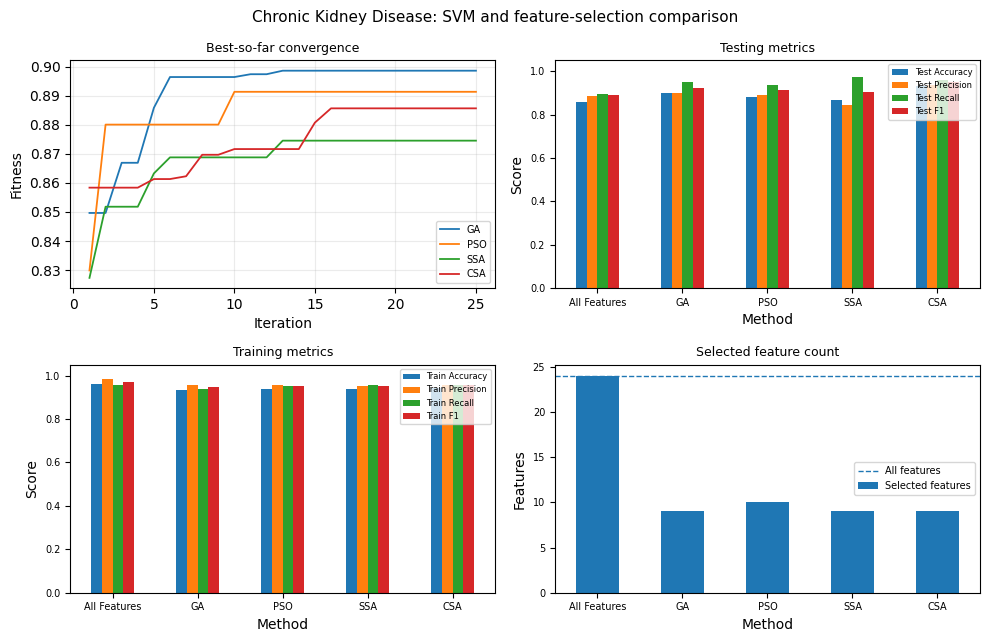

Saved: saved_figures/chronic_kidney_disease_dashboard.png


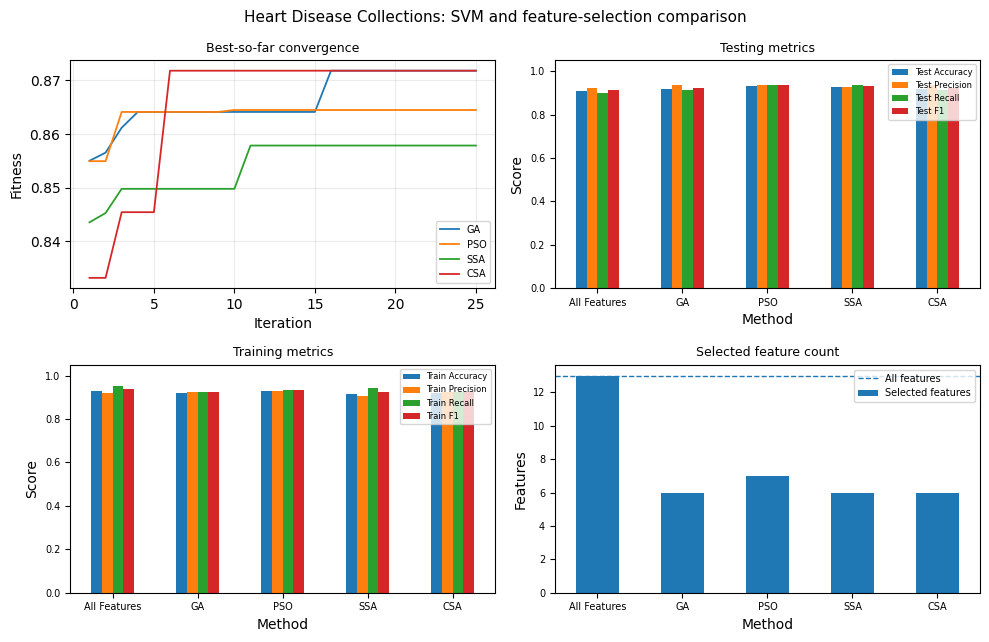

Saved: saved_figures/heart_disease_collections_dashboard.png


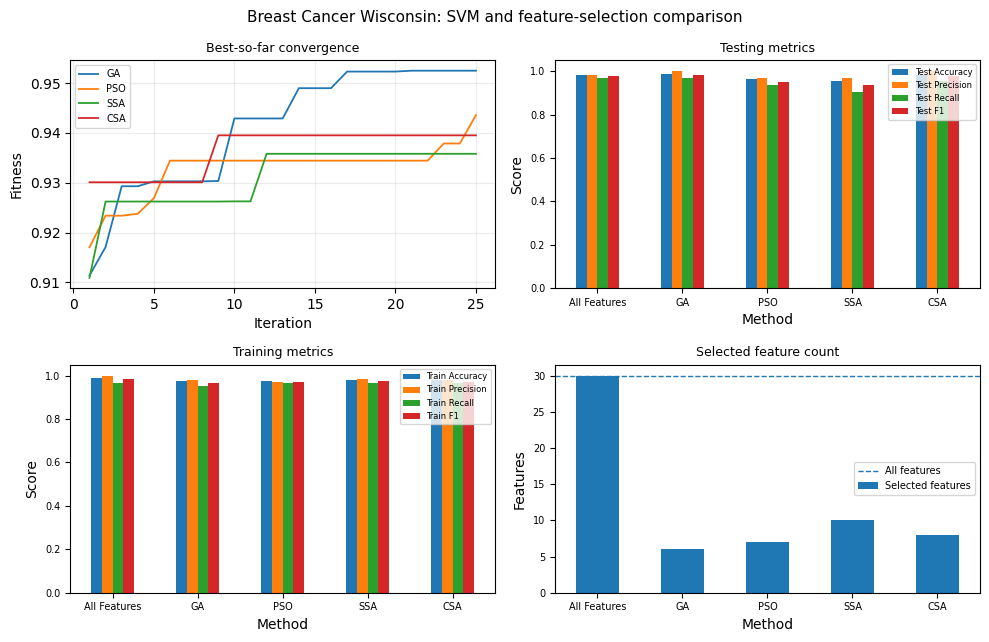

Saved: saved_figures/breast_cancer_wisconsin_dashboard.png


In [15]:
method_order = ['All Features', 'GA', 'PSO', 'SSA', 'CSA']
for dataset_name in datasets:
    subset = results_df[results_df['Dataset'].eq(dataset_name)].set_index('Method').reindex(method_order)
    fig, axes = plt.subplots(2, 2, figsize=(10, 6.5))

    for name in ALGORITHMS:
        hist = convergence[(dataset_name, name)]
        axes[0, 0].plot(range(1, len(hist)+1), hist, linewidth=1.3, label=name)
    axes[0, 0].set_title('Best-so-far convergence', fontsize=9)
    axes[0, 0].set_xlabel('Iteration')
    axes[0, 0].set_ylabel('Fitness')
    axes[0, 0].grid(alpha=0.25)
    axes[0, 0].legend(fontsize=7)

    subset[['Test Accuracy', 'Test Precision', 'Test Recall', 'Test F1']].plot(
        kind='bar', ax=axes[0, 1], fontsize=7
    )
    axes[0, 1].set_title('Testing metrics', fontsize=9)
    axes[0, 1].set_ylim(0, 1.05)
    axes[0, 1].set_ylabel('Score')
    axes[0, 1].tick_params(axis='x', rotation=0)
    axes[0, 1].legend(fontsize=6)

    subset[['Train Accuracy', 'Train Precision', 'Train Recall', 'Train F1']].plot(
        kind='bar', ax=axes[1, 0], fontsize=7
    )
    axes[1, 0].set_title('Training metrics', fontsize=9)
    axes[1, 0].set_ylim(0, 1.05)
    axes[1, 0].set_ylabel('Score')
    axes[1, 0].tick_params(axis='x', rotation=0)
    axes[1, 0].legend(fontsize=6)

    subset['Selected features'].plot(kind='bar', ax=axes[1, 1], fontsize=7)
    axes[1, 1].axhline(subset['Total features'].iloc[0], linestyle='--', linewidth=1, label='All features')
    axes[1, 1].set_title('Selected feature count', fontsize=9)
    axes[1, 1].set_ylabel('Features')
    axes[1, 1].tick_params(axis='x', rotation=0)
    axes[1, 1].legend(fontsize=7)

    fig.suptitle(f'{dataset_name}: SVM and feature-selection comparison', fontsize=11)
    fig.tight_layout()
    save_and_show(fig, f'{safe_filename(dataset_name)}_dashboard.png')

## 15. Optimization runtime figure

Runtime remains excluded from the final result tables, but the figure is retained and saved.

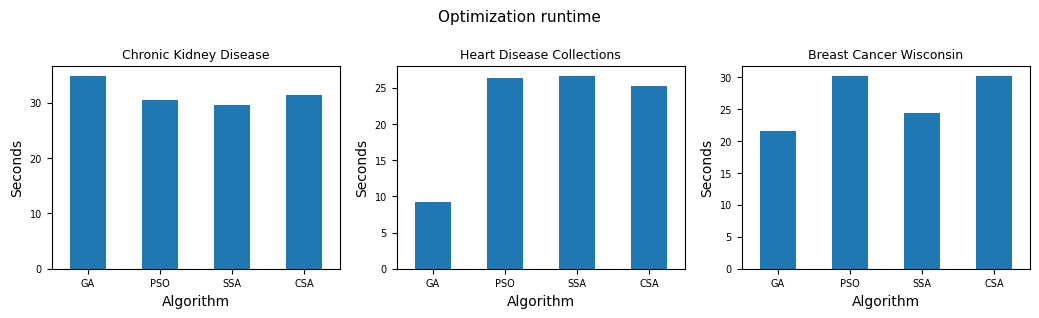

Saved: saved_figures/optimization_runtime.png


In [16]:
runtime_df = pd.DataFrame([
    {'Dataset': d, 'Algorithm': a, 'Runtime (s)': v}
    for (d, a), v in runtimes.items()
])
fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.2))
for ax, dataset_name in zip(axes, datasets.keys()):
    s = runtime_df[runtime_df['Dataset'].eq(dataset_name)].set_index('Algorithm').reindex(ALGORITHMS.keys())
    s['Runtime (s)'].plot(kind='bar', ax=ax, fontsize=7)
    ax.set_title(dataset_name, fontsize=9)
    ax.set_ylabel('Seconds')
    ax.tick_params(axis='x', rotation=0)
fig.suptitle('Optimization runtime', fontsize=11)
fig.tight_layout()
save_and_show(fig, 'optimization_runtime.png')

## 16. Best feature-selection result for each dataset

The best selected-feature method is identified by the highest **testing F1-score** for visualization only. The test set is never used by the search itself.


In [17]:
best_method_rows = []
for dataset_name in datasets:
    candidates = results_df[
        results_df['Dataset'].eq(dataset_name) & results_df['Method'].isin(ALGORITHMS.keys())
    ].copy()
    best_row = candidates.sort_values(
        ['Test F1', 'Test Recall', 'Selected features'],
        ascending=[False, False, True]
    ).iloc[0]
    best_method_rows.append({
        'Dataset': dataset_name,
        'Best feature-selection method': best_row['Method'],
        'Classifier': best_row['Classification algorithm'],
        'Test Accuracy': best_row['Test Accuracy'],
        'Test Precision': best_row['Test Precision'],
        'Test Recall': best_row['Test Recall'],
        'Test F1': best_row['Test F1'],
        'Selected features': int(best_row['Selected features'])
    })
best_methods_df = pd.DataFrame(best_method_rows)
best_methods_df.round(4)


,Dataset,Best feature-selection method,Classifier,Test Accuracy,Test Precision,Test Recall,Test F1,Selected features
0,Chronic Kidney Disease,CSA,Support Vector Machine (RBF-SVM),0.9333,0.9367,0.9610,0.9487,9
1,Heart Disease Collections,PSO,Support Vector Machine (RBF-SVM),0.9333,0.9375,0.9375,0.9375,7
2,Breast Cancer Wisconsin,GA,Support Vector Machine (RBF-SVM),0.9883,1.0000,0.9688,0.9841,6


## 17. Confusion matrices for the best selected-feature results


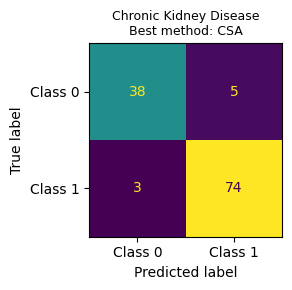

Saved: saved_figures/chronic_kidney_disease_csa_confusion_matrix.png


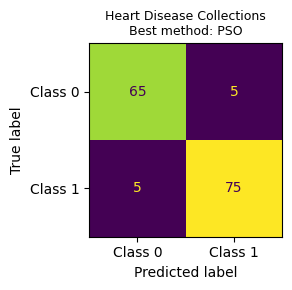

Saved: saved_figures/heart_disease_collections_pso_confusion_matrix.png


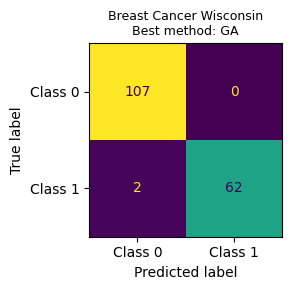

Saved: saved_figures/breast_cancer_wisconsin_ga_confusion_matrix.png


In [18]:
for _, row in best_methods_df.iterrows():
    dataset_name = row['Dataset']
    method = row['Best feature-selection method']
    _, _, _, y_test = dataset_splits[dataset_name]
    y_pred = experiment_artifacts[(dataset_name, method)]['test_pred']
    cm = confusion_matrix(y_test, y_pred)

    fig, ax = plt.subplots(figsize=(3.4, 3.0))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 0', 'Class 1'])
    disp.plot(ax=ax, colorbar=False, values_format='d')
    ax.set_title(f'{dataset_name}\nBest method: {method}', fontsize=9)
    fig.tight_layout()
    save_and_show(fig, f'{safe_filename(dataset_name)}_{method.lower()}_confusion_matrix.png')


## 18. Correlation heatmaps for the best selected features

Each heatmap shows Pearson correlations among the features selected by the best feature-selection method. To keep figures readable, at most the 20 selected features with the largest absolute correlation to the target are displayed.


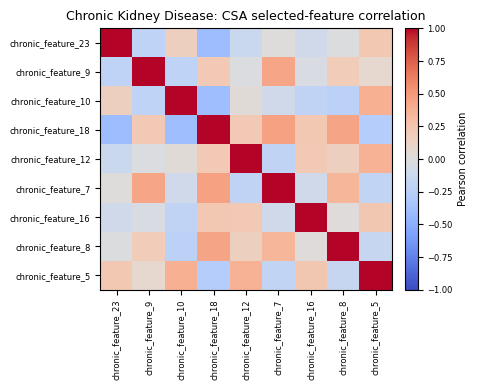

Saved: saved_figures/chronic_kidney_disease_csa_selected_feature_heatmap.png


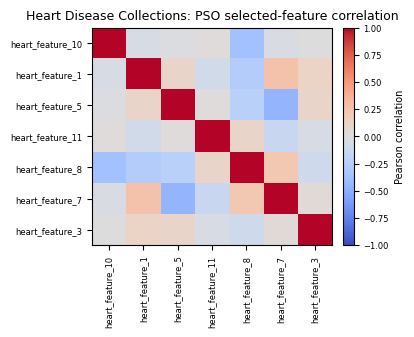

Saved: saved_figures/heart_disease_collections_pso_selected_feature_heatmap.png


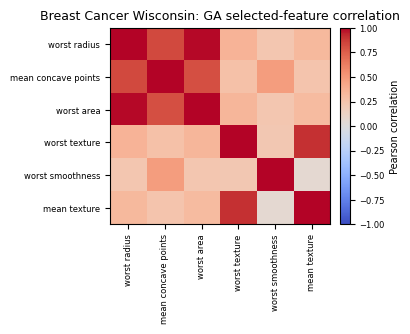

Saved: saved_figures/breast_cancer_wisconsin_ga_selected_feature_heatmap.png


In [19]:
MAX_HEATMAP_FEATURES = 20
for _, row in best_methods_df.iterrows():
    dataset_name = row['Dataset']
    method = row['Best feature-selection method']
    X_train, _, y_train, _ = dataset_splits[dataset_name]
    selected_cols = experiment_artifacts[(dataset_name, method)]['columns']

    numeric_selected = X_train[selected_cols].apply(pd.to_numeric, errors='coerce')
    imputed = numeric_selected.fillna(numeric_selected.median(numeric_only=True))
    target_corr = imputed.corrwith(pd.Series(y_train.values, index=imputed.index)).abs().sort_values(ascending=False)
    shown_cols = target_corr.head(MAX_HEATMAP_FEATURES).index.tolist()
    corr = imputed[shown_cols].corr()

    size = min(7.0, max(4.2, 0.32 * len(shown_cols) + 2.0))
    fig, ax = plt.subplots(figsize=(size, size * 0.82))
    image = ax.imshow(corr.values, vmin=-1, vmax=1, cmap='coolwarm', aspect='auto')
    ax.set_xticks(range(len(shown_cols)))
    ax.set_yticks(range(len(shown_cols)))
    ax.set_xticklabels(shown_cols, rotation=90, fontsize=6)
    ax.set_yticklabels(shown_cols, fontsize=6)
    ax.set_title(f'{dataset_name}: {method} selected-feature correlation', fontsize=9)
    cbar = fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Pearson correlation', fontsize=7)
    cbar.ax.tick_params(labelsize=6)
    fig.tight_layout()
    save_and_show(fig, f'{safe_filename(dataset_name)}_{method.lower()}_selected_feature_heatmap.png')


## 19. Saved figure files


In [20]:
saved_figure_df = pd.DataFrame({'Saved figure': sorted(str(p) for p in FIGURE_DIR.glob('*.png'))})
saved_figure_df


,Saved figure
0,saved_figures/all_datasets_convergence.png
1,saved_figures/breast_cancer_wisconsin_dashboar...
2,saved_figures/breast_cancer_wisconsin_ga_confu...
3,saved_figures/breast_cancer_wisconsin_ga_selec...
4,saved_figures/chronic_kidney_disease_csa_confu...
5,saved_figures/chronic_kidney_disease_csa_selec...
6,saved_figures/chronic_kidney_disease_dashboard...
7,saved_figures/heart_disease_collections_dashbo...
8,saved_figures/heart_disease_collections_pso_co...
9,saved_figures/heart_disease_collections_pso_se...


## Notes

- **SSA** means Salp Swarm Algorithm.
- All baseline and selected-feature models use a balanced RBF-SVM pipeline.
- The shared fitness is the exact quantity displayed in every convergence curve.
- Final tables report training and testing Accuracy, Precision, Recall, and F1, together with selected-feature counts.
- Every figure is saved to `saved_figures/` at reduced dimensions and 160 DPI.
- The best-result confusion matrix and selected-feature correlation heatmap are generated separately for each dataset.
- The larger population and iteration count improve search stability, but publication-quality studies should also repeat each optimizer across multiple random seeds and report mean and standard deviation.
- Results from simulated fallback datasets are demonstrations only. Use the Kaggle CSV files for study conclusions.
